The content of this lab is based on the material provided by **Jake VanderPlas** in his machine learning tutorial, **[Scikit-learn Tutorial](https://github.com/jakevdp/sklearn_tutorial)**.

## Aim
This lab aims to familiarize you with the basics of machine learning, and some skills useful in practice using `scikit-learn`, a machine learning library implemented in Python. 

## Setting up your system
Check whether you have the required packages:

- `Python` version 3.7+
- `numpy` version 1.17+: http://www.numpy.org/
- `scipy` version 1.7+: http://www.scipy.org/
- `matplotlib` version 3.1+: http://matplotlib.org/
- `scikit-learn` version 1.1+: http://scikit-learn.org
- `ipython`/`jupyter` version 7.8+, with notebook support: http://ipython.org
- `seaborn` version 0.12, used mainly for plot styling: https://seaborn.pydata.org/

The easiest way to get these is to use the [conda](http://store.continuum.io/) environment manager.
You can download and install [miniconda](https://docs.conda.io/en/latest/miniconda.html).

The following command will install all required packages:
```
$ conda install numpy scipy matplotlib scikit-learn ipython-notebook seaborn
```

Alternatively, you can download and install the (very large) Anaconda software distribution, found at https://store.continuum.io/.

### Checking your installation

Run the following code to check the versions of the packages on your system:

In [6]:
from __future__ import print_function

!python --version

import numpy
print('numpy:', numpy.__version__)

import scipy
print('scipy:', scipy.__version__)

import matplotlib
print('matplotlib:', matplotlib.__version__)

import sklearn
print('scikit-learn:', sklearn.__version__)

import IPython
print('IPython:', IPython.__version__)

import seaborn
print('Seaborn:',seaborn.__version__)

Python 3.10.19
numpy: 2.2.6
scipy: 1.15.2
matplotlib: 3.10.7
scikit-learn: 1.7.2
IPython: 8.37.0
Seaborn: 0.13.2


## What is scikit-learn?
[Scikit-learn](https://scikit-learn.org/) is an open-source machine learning library that supports supervised and unsupervised learning. It also provides various tools for model fitting, data preprocessing, model selection, model evaluation, and many other utilities.

Scikit-learn deals with learning information from one or more datasets that are represented as 2D arrays. They can be understood as a list of multi-dimensional observations. We say that the first axis of these arrays is the samples axis, while the second is the features axis.

![Data Layout](./images/05.02-samples-features.png)

(Figure from the [Python Data Science Handbook](https://github.com/jakevdp/PythonDataScienceHandbook))

Let's check the Iris dataset. The dataset contains 3 classes of 50 instances each, where each class refers to a type of iris plant. 

The features Information:

1. sepal length in cm
2. sepal width in cm
3. petal length in cm
4. petal width in cm
5. class:
    - Iris Setosa display
    - Iris Versicolor
    - Iris Virginica

- Iris Setosa


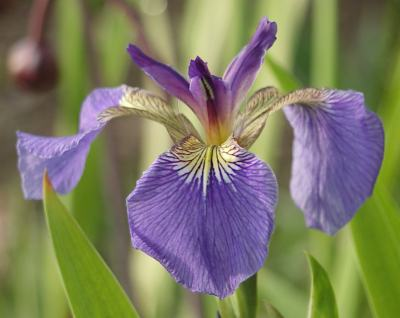

- Iris Versicolor


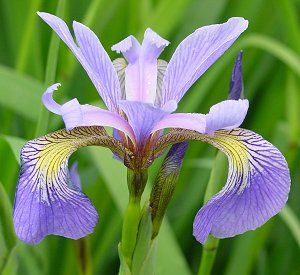

- Iris Virginica


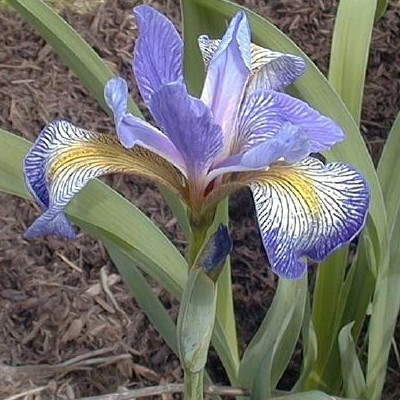

In [1]:
from IPython.display import Image, display
print('- Iris Setosa') 
display(Image(filename='./images/iris_setosa.jpg'))

print('- Iris Versicolor') 
display(Image(filename='./images/iris_versicolor.jpg'))

print('- Iris Virginica') 
display(Image(filename='./images/iris_virginica.jpg'))


The [Iris dataset](https://archive.ics.uci.edu/ml/datasets/iris) embeds in scikit-learn along with a helper function to load it into numpy arrays. You can load the data by importing datasets as follows: 

In [7]:
from sklearn import datasets

iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Analyse the iris dataset using the provided keys and printout:
   - Number of samples
   - Number of features
   - Feature names
   - Target names

In [22]:
# TODO
print("Nr of samples: ", len(iris.data))
print("Nr of features:", len(iris.feature_names))
print(iris.feature_names)
print(iris.target_names)


print("shape of data:", iris.data.shape)

Nr of samples:  150
Nr of features: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
shape of data: (150, 4)


Let's plot the dataset using 2 features and color code the samples based on the target classes.

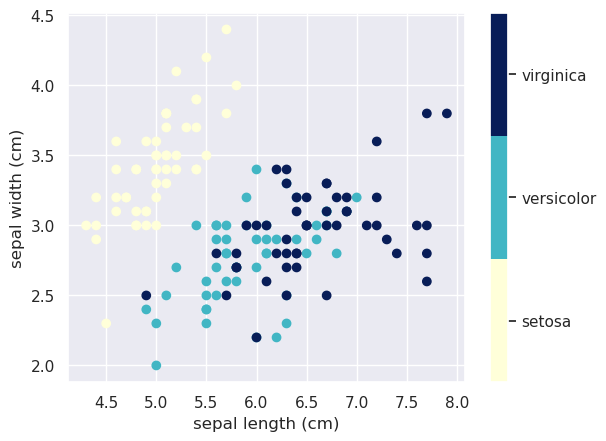

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

x_index = 0
y_index = 1

# This formatter will label the colorbar with the correct target names
formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[i])

plt.scatter(iris.data[:, x_index], iris.data[:, y_index],
            c=iris.target, cmap=plt.get_cmap('YlGnBu', 3))
plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.clim(-0.5, 2.5)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.show();

The dataset contains **4** features. Try different combinations of the features by changing the values of `x_index` and `y_index` and identify features that maximally separate the three classes.

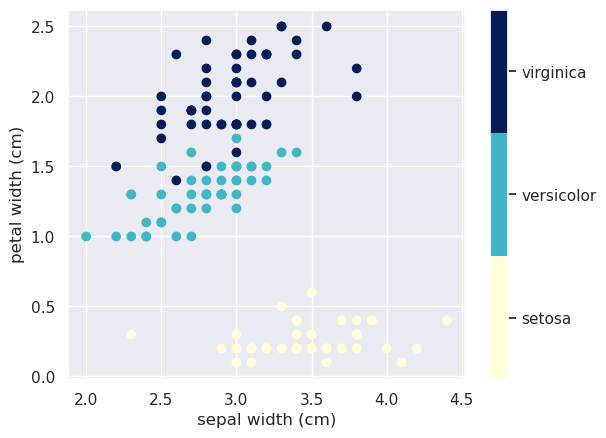

In [57]:
# TODO

x_index = 1
y_index = 3

# This formatter will label the colorbar with the correct target names
formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[i])

plt.scatter(iris.data[:, x_index], iris.data[:, y_index],
            c=iris.target, cmap=plt.get_cmap('YlGnBu', 3))
plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.clim(-0.5, 2.5)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.show();


## Available Data on Scikit-learn
The data in scikit-learn comes in three flavors:

- **[Toy Datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html) and [Loading Other Datasets](https://scikit-learn.org/stable/datasets/loading_other_datasets.html):** these small datasets are packaged with the scikit-learn installation,
  and can be downloaded using the tools in ``sklearn.datasets.load_*``.
- **[Real World Datasets](https://scikit-learn.org/stable/datasets/real_world.html):** these large datasets are available for download, and scikit-learn
  includes tools that streamline this process. These tools can be found in ``sklearn.datasets.fetch_*``.
- **[Generated Data](https://scikit-learn.org/stable/datasets/sample_generators.html):** there are several datasets that are generated from models based on a random seed. These are available in the ``sklearn.datasets.make_*``.

You can explore the available datasets by importing the ``datasets`` submodule from ``sklearn`` and typing  ``datasets.load_`` or ``datasets.fetch_`` or ``datasets.make_`` followed by pressing the TAB button from the keyboard.

In [68]:
from sklearn import datasets
from sklearn.datasets import fetch_20newsgroups

#datasets.load_
# datasets.fetch_
#datasets.make_

wine = datasets.load_wine()
print(wine.keys())



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])


## The Scikit-learn Estimator Object

Every algorithm in scikit-learn can be called via an ''Estimator'' object. For instance a linear regression is implemented as:

In [69]:
from sklearn.linear_model import LinearRegression



**Estimator parameters**: All the parameters of an estimator can be set when it is instantiated, and have suitable default values:

`LinearRegression(*, fit_intercept=True, normalize='deprecated', copy_X=True, n_jobs=None, positive=False)`

## Supervised Learning: Classification and Regression

In **Supervised Learning**, the dataset consists of both features and labels. The task is to construct an estimator that can predict an object's label given the set of features. A relatively simple example is predicting the species of Iris given a set of measurements of its flower. This is a relatively simple task. 
Some more complicated examples are:

- given a multicolor image of an object through a telescope, determine whether that object is a star, a quasar, or a galaxy.
- given a photograph of a person, identify the person in the photo.
- given a list of movies a person has watched and their rating
  of the movie, recommend a list of movies they would like
  (So-called *recommender systems*: a famous example is the [Netflix Prize](http://en.wikipedia.org/wiki/Netflix_prize)).

What these tasks have in common is that one or more unknown quantities are associated with the object, which needs to be determined from other observed quantities.

Supervised learning is further broken down into two categories: 
 - regression
 - classification

In **regression**, the label is continuous, while in **classification**, the label is discrete. For example, we might wish to estimate the age of an object based on such observations: this would be a regression problem because the label (age) is a continuous quantity. On the other hand, in astronomy, determining whether an object is a star, a galaxy, or a quasar is a classification problem: the label is one of the three distinct categories.

### Regression Example

One of the simplest regression problems is fitting a line to data, also known as **linear regression**.
Scikit-learn also contains more sophisticated regression algorithms. Below you can see how to initialize the linear regression estimator with the default hyperparameters.

`LinearRegression(*, fit_intercept=True, normalize='deprecated', copy_X=True, n_jobs=None, positive=False)`

In [107]:
LR = LinearRegression()

print(LR)
print(LR.fit_intercept) #You can see which hyperparameter is selected by checking it specifically.

LinearRegression()
True


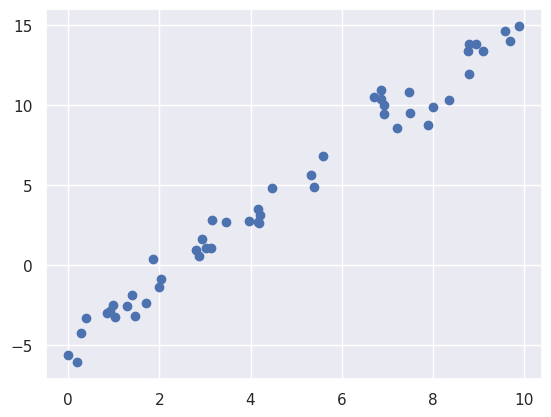

In [108]:
# Setting randomstate to a specific number to be able to regenerate the same numbers every time
rng = np.random.RandomState(1)

# Creating 50 samples within a range 0 and 10
x = 10 * rng.rand(50)

# y = 2x - 5 + epsilon
y = 2 * x - 5 + rng.randn(50)

plt.scatter(x, y);

In [109]:
x.shape

(50,)

The input data for sklearn, as we mentioned earlier, is 2D. In the case of the above dataset, the data should be represented as: (samples == 50 x features == 1). You can use `reshape(-1,1)` to reshape the data.

In [110]:
X = x.reshape(-1,1)
X.shape

(50, 1)

In [111]:
# Fit the model on the data
LR.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Estimated Model parameters**: When data is *fit* with an estimator, parameters are estimated from the data at hand (training set). All the estimated parameters are attributes of the estimator object ending by an underscore:


In [112]:
print(np.round(LR.coef_))
print(np.round(LR.intercept_))

[2.]
-5.0


The model found a line with a slope 2 and intercept -5.

$y = 2x - 5$

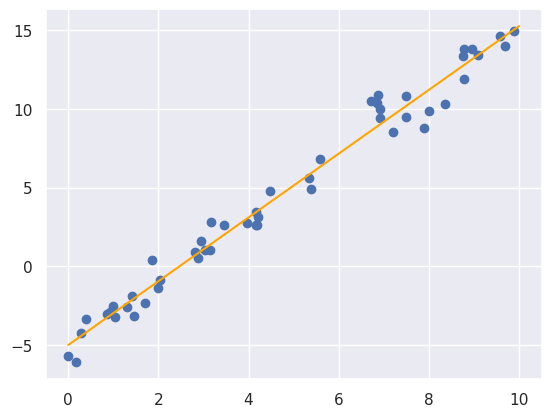

In [113]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# Plot the data and the model prediction

# Creating 100 samples evenly spaced numbers within the of range 0 and 10 .
xfit = np.linspace(0, 10, 100).reshape(-1,1)

# Pefrom predicition on 
yfit = LR.predict(xfit)

plt.scatter(X, y)
plt.plot(xfit, yfit, color='orange');

In [114]:
# Call the "score" method of the built model (LR) on the X and y.

# TODO

print("Score between X & Y:", LR.score(X, y))


Score between X & Y: 0.9790800609430612


In [115]:
# What does the above score mean?

# TODO

print("Your linear regression model explains about 97.9% of the variation in y based on X.")


Your linear regression model explains about 97.9% of the variation in y based on X.


Achieved score:  0.9966656744431245


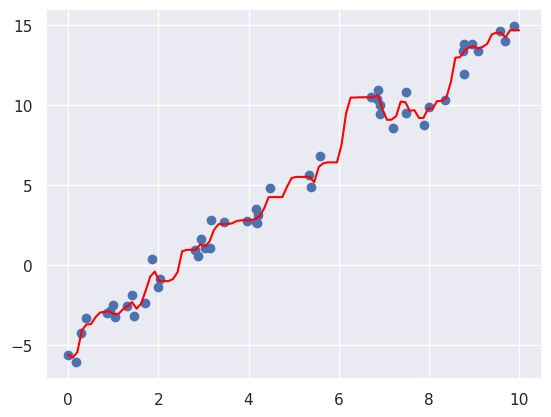

In [118]:
# Fit a Random Forest and plot the data and the model prediction simillar to the built LR model
# What is the achived score?
from sklearn.ensemble import RandomForestRegressor

# TODO
forest = RandomForestRegressor()

forest.fit(X,y)

# Plot the data and the model prediction

# Creating 100 samples evenly spaced numbers within the of range 0 and 10 .
xfit = np.linspace(0, 10, 100).reshape(-1,1)

# Pefrom predicition on 
yfit = forest.predict(xfit)
plt.scatter(X, y)
plt.plot(xfit, yfit, color='red');

print("Achieved score: ", forest.score(X,y))




Explore the ``RandomForestRegressor`` object using IPython's help features by adding a question mark (**?**) after the object.

   - What arguments are available to ``RandomForestRegressor``?
   - How does the above plot change if you change these arguments?

These class-level arguments are known as *hyperparameters*, and we will discuss later how you to select hyperparameters in the model validation section.

In [119]:
# TODO

# Fit a Random Forest and plot the data and the model prediction simillar to the built LR model
# What is the achived score?
from sklearn.ensemble import RandomForestRegressor

# TODO
RandomForestRegressor?




Init signature:
RandomForestRegressor(
    n_estimators=100,
    *,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=1.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest regressor.

A random forest is a meta estimator that fits a number of decision tree
regressors on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the whole dataset is use

Achieved score:  0.9890281623300794


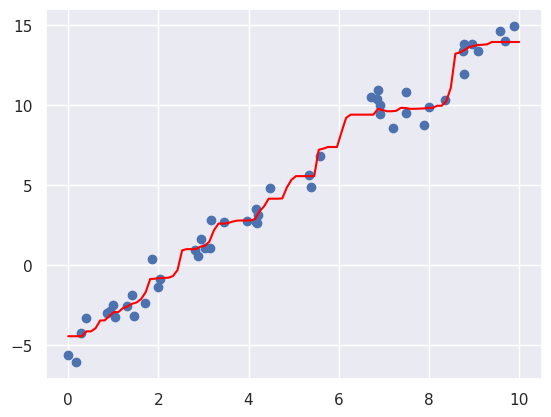

In [147]:
# Fit a Random Forest and plot the data and the model prediction simillar to the built LR model
# What is the achived score?
from sklearn.ensemble import RandomForestRegressor

# TODO
forest = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=3)

forest.fit(X,y)

# Plot the data and the model prediction

# Creating 100 samples evenly spaced numbers within the of range 0 and 10 .
xfit = np.linspace(0, 10, 100).reshape(-1,1)

# Pefrom predicition on 
yfit = forest.predict(xfit)
plt.scatter(X, y)
plt.plot(xfit, yfit, color='red');

print("Achieved score: ", forest.score(X,y))




### Classification Example
K nearest neighbors (kNN) is one of the simplest learning strategies: given a new unknown observation, kNN looks up in the reference database to identify the data sample with the closest features and assign the predominant class.

In [152]:
from sklearn import neighbors
from sklearn import datasets

iris = datasets.load_iris()

X, y = iris.data, iris.target

n_neighbors = 5

# Create the model
knn = neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)

# Fit the model
knn.fit(X, y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [153]:
# What kind of iris has 3cm x 2cm sepal and 3cm x 2cm petal?
# Call the "predict" method:
result = knn.predict([[3, 2, 3, 2],])
print(iris.target_names[result])

['versicolor']


In [154]:
# The probability that a new observation has with regards to each categorical label
knn.predict_proba([[3, 2, 3, 2],])

array([[0. , 0.8, 0.2]])

#### Visualizing a Classifier's Decision Boundary

In [155]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
sns.set_theme()

def plot_decision_boundary(clf, dataset, isPCA=False, show_misclassified=False):

    '''To show the classifier's decision boundary, we apply either 
       Principal Component Analysis (PCA) to the data and consider 
       only the two components or only the first two features.'''
    
    if isPCA:   
        pca = PCA(n_components=2)
        pca.fit(dataset.data)
        X = pca.transform(dataset.data)
        x_label='Component 1'
        y_label='Component 2'
    else:
        X = dataset.data[:, :2]
        x_label=dataset.feature_names[0]
        y_label=dataset.feature_names[1]
    
    y = dataset.target
    clf.fit(X, y)
    y_pred = clf.predict(X)
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF00BB', '#00FF00', '#0000FF']
    
    disp = DecisionBoundaryDisplay.from_estimator(
    clf, 
    X,
    cmap=cmap_light,
    response_method="predict",
    xlabel=x_label, 
    ylabel=y_label,
    alpha=0.5,
    )

    sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=dataset.target_names[y],
    palette=cmap_bold,
    alpha=1.0,
    edgecolor="black"
    )

    if show_misclassified:
        c=0
        for i, i_value in enumerate(dataset.target):
            if y_pred[i] != i_value:
                c+=1
                plt.scatter(X[i, 0], 
                            X[i, 1],
                            c='red', 
                            marker="x")
        print(c, 'misclassified samples (showed with red cross).')

    plt.show()

24 misclassified samples (showed with red cross).


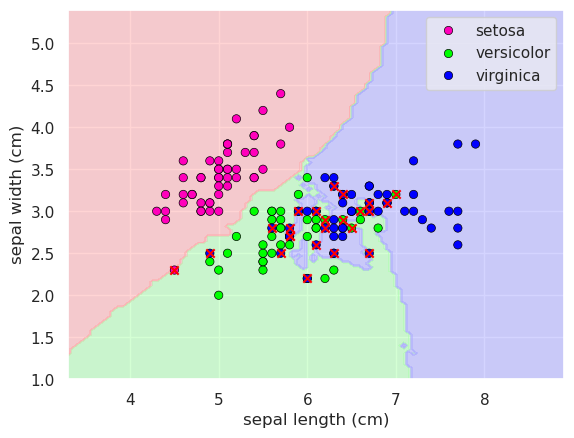

In [157]:
from sklearn import neighbors
from sklearn import datasets

iris = datasets.load_iris()
n_neighbors = 5

# Create the model
knn = neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)

plot_decision_boundary(knn, iris, isPCA=False, show_misclassified=True)

27 misclassified samples (showed with red cross).


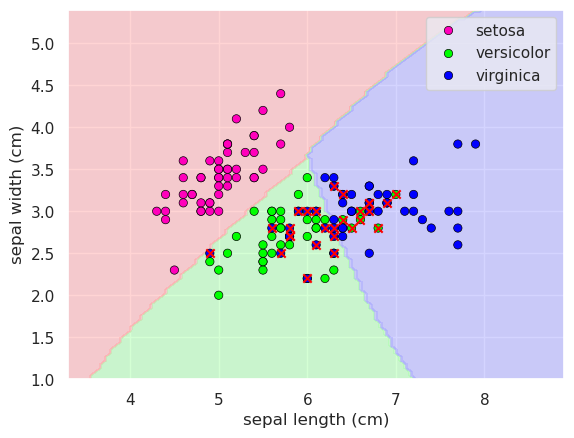

In [167]:
from sklearn import svm
from sklearn import datasets

iris = datasets.load_iris()

#TODO 
#Fit a support vector machine (SVM) and plot the decision boundaries 

svmTest = svm.SVC()

plot_decision_boundary(svmTest, iris, isPCA=False, show_misclassified=True)



## Unsupervised Learning: Dimensionality Reduction and Clustering
In **unsupervised learning**, we are interested in finding similarities between the objects in question when the data has no label. In a sense,
you can think of unsupervised learning as a means of discovering labels from the data.
Unsupervised learning comprises tasks such as *dimensionality reduction*, *clustering*, and *density estimation*. For example, in the iris data discussed above, we can use unsupervised methods to determine combinations of the measurements that best display the data's structure. As we'll see below, such a projection of the data can be used to visualize the four-dimensional dataset in two dimensions. Some more involved unsupervised learning problems are:

- given detailed observations of distant galaxies, determine which features or combinations of features best summarize the information.
- given a mixture of two sound sources (for example, a person talking over some music), separate the two (this is called the [blind source separation](http://en.wikipedia.org/wiki/Blind_signal_separation) problem).
- given a video, isolate a moving object and categorize it in relation to other moving objects which have been seen.

Sometimes the two may even be combined, e.g., unsupervised learning can be used to find useful features in heterogeneous data, and then these features can be used within a supervised framework.

### Dimensionality Reduction: PCA

Principle Component Analysis (PCA) is a dimension reduction technique that can find the combinations of variables that explain the most variance.

Consider the iris dataset. It cannot be visualized in a single 2D plot, as it has four features. We are going to extract two combinations of sepal and petal dimensions to visualize it:

In [1]:
from sklearn import datasets
from sklearn.decomposition import PCA

iris = datasets.load_iris()
X, y = iris.data, iris.target

#You can set `n_components` to be a number between 1 and the number of features. 
#Or from a range of values between 0 and 1. In the second case, e.g., n_components=0.95 
#represents how many components can retain 95% of the variance.

pca = PCA(n_components=2) 
pca.fit(X)
X_reduced = pca.transform(X)
print("Reduced dataset shape:", X_reduced.shape)

Reduced dataset shape: (150, 2)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

plt.scatter(X_reduced[:, 0], 
            X_reduced[:, 1], 
            c=y,
            cmap=plt.cm.get_cmap('RdYlBu', 3),
            alpha=0.5)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show();

print("Meaning of the two components:")
for component in pca.components_:
    print(" + ".join("%.3f x %s" % (value, name)
                     for value, name in zip(component,
                                            iris.feature_names)))

### Clustering: k-means

The clustering analysis groups homogeneous observations with respect to a given criterion, to find number of **clusters** in the data.

Note that these clusters will uncover the relevant hidden structure of the data only if the criterion used highlights it.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from sklearn.cluster import KMeans

iris = datasets.load_iris()
X, y = iris.data, iris.target

k_means = KMeans(n_clusters=3, random_state=0)
# We use the iris data to fit the k_means.
k_means.fit(X)

# We use the reduced data using PCA for plotting the results. The colors represent 3 clusters. 
# The color order is not important (comparing the below and above plots.)
plt.scatter(X_reduced[:, 0], 
            X_reduced[:, 1], 
            c=k_means.labels_,
            cmap=plt.get_cmap('RdYlBu', 3),
            alpha=0.5);

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show();

## Dimensionality Reduction: Principal Component Analysis in-depth

Here we'll now explore **Principal Component Analysis**, in more depth, which is an extremely useful linear dimensionality reduction technique.

### Introducing Principal Component Analysis

Principal Component Analysis is a very powerful unsupervised method for *dimensionality reduction* in data.  It's easiest to visualize by looking at a two-dimensional dataset:

In [ ]:
np.random.seed(1)
X = np.dot(np.random.random(size=(2, 2)), np.random.normal(size=(2, 200))).T
plt.plot(X[:, 0], X[:, 1], 'o')
plt.axis('equal');

We can see that there is a definite trend in the data. What PCA seeks to do is to find the **Principal Axes** in the data, and explain how important those axes are in describing the data distribution:

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)
print(pca.explained_variance_)
print(pca.components_)

To see what these numbers mean, let's view them as vectors plotted on top of the data:

In [ ]:
plt.plot(X[:, 0], X[:, 1], 'o', alpha=0.5)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    plt.plot([0, v[0]], [0, v[1]], '-k', lw=3)
plt.axis('equal');

Notice that one vector is longer than the other. In a sense, this tells us that that direction in the data is somehow more "important" than the other direction.
The explained variance quantifies this measure of "importance" in direction.

Another way to think of it is that the second principal component could be **completely ignored** without much loss of information! Let's see what our data look like if we only keep 95% of the variance:

In [ ]:
clf = PCA(0.95) # keep 95% of variance
X_trans = clf.fit_transform(X)
print(X.shape)
print(X_trans.shape)

By specifying that we want to throw away 5% of the variance, the data is now compressed by a factor of 50%! Let's see what the data look like after this compression:

In [ ]:
X_new = clf.inverse_transform(X_trans)
plt.plot(X[:, 0], X[:, 1], 'o', alpha=0.2)
plt.plot(X_new[:, 0], X_new[:, 1], 'ob', alpha=0.8)
plt.axis('equal');

The light points are the original data, while the dark points are the projected version.  We see that after truncating 5% of the variance of this dataset and then reprojecting it, the "most important" features of the data are maintained, and we've compressed the data by 50%!

This is the sense in which "dimensionality reduction" works: if you can approximate a data set in a lower dimension, you can often have an easier time visualizing it or fitting complicated models to the data.

### Application of PCA to Digits

The dimensionality reduction might seem a bit abstract in two dimensions, but the projection and dimensionality reduction can be extremely useful when visualizing high-dimensional data.  Let's take a quick look at the application of PCA to the digits data we looked at before:

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
pca = PCA(2)  # project from 64 to 2 dimensions
Xproj = pca.fit_transform(X)
print(X.shape)
print(Xproj.shape)

In [ ]:
plt.scatter(Xproj[:, 0], Xproj[:, 1], c=y, edgecolor='none', alpha=0.5,
            cmap=plt.get_cmap('nipy_spectral', 10))
plt.colorbar();

This gives us an idea of the relationship between the digits. Essentially, we have found the optimal stretch and rotation in 64-dimensional space that allows us to see the layout of the digits, **without reference** to the labels.

### What do the Components Mean?

PCA is a very useful dimensionality reduction algorithm, because it has a very intuitive interpretation via *eigenvectors*.
The input data is represented as a vector: in the case of the digits, our data is

$$
x = [x_1, x_2, x_3 \cdots]
$$

but what this really means is

$$
image(x) = x_1 \cdot{\rm (pixel~1)} + x_2 \cdot{\rm (pixel~2)} + x_3 \cdot{\rm (pixel~3)} \cdots
$$

If we reduce the dimensionality in the pixel space to (say) 6, we recover only a partial image:

In [ ]:
from fig_code.figures import plot_image_components

with plt.style.context('seaborn-v0_8-white'):
    plot_image_components(digits.data[0])

But the pixel-wise representation is not the only choice. We can also use other *basis functions*, and write something like

$$
image(x) = {\rm mean} + x_1 \cdot{\rm (basis~1)} + x_2 \cdot{\rm (basis~2)} + x_3 \cdot{\rm (basis~3)} \cdots
$$

What PCA does is to choose optimal **basis functions** so that only a few are needed to get a reasonable approximation.
The low-dimensional representation of our data is the coefficients of this series, and the approximate reconstruction is the result of the sum:

In [ ]:
from fig_code.figures import plot_pca_interactive
plot_pca_interactive(digits.data)

Here we see that with only six PCA components, we recover a reasonable approximation of the input!

Thus we see that PCA can be viewed from two angles. It can be viewed as **dimensionality reduction**, or it can be viewed as a form of **lossy data compression** where the loss favors noise. In this way, PCA can be used as a **filtering** process as well.

### Choosing the Number of Components

But how much information have we thrown away?  We can figure this out by looking at the **explained variance** as a function of the components:

In [ ]:
pca = PCA().fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Here we see that our two-dimensional projection loses a lot of information (as measured by the explained variance) and that we'd need about 20 components to retain 90% of the variance.  Looking at this plot for a high-dimensional dataset can help you understand the level of redundancy present in multiple observations.

### PCA as data compression

As we mentioned, PCA can be used for is a sort of data compression. Using a small ``n_components`` allows you to represent a high dimensional point as a sum of just a few principal vectors.

Here's what a single digit looks like as you change the number of components:

In [ ]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, ax in enumerate(axes.flat):
    pca = PCA(i + 1).fit(X)
    im = pca.inverse_transform(pca.transform(X[20:21]))

    ax.imshow(im.reshape((8, 8)), cmap='binary')
    ax.text(0.95, 0.05, 'n = {0}'.format(i + 1), ha='right',
            transform=ax.transAxes, color='red')
    ax.set_xticks([])
    ax.set_yticks([])

Let's take another look at this by using IPython's ``interact`` functionality to view the reconstruction of several images at once:

In [ ]:
from ipywidgets import interact

def plot_digits(n_components):
    fig = plt.figure(figsize=(8, 8))
    plt.subplot(1, 1, 1, frameon=False, xticks=[], yticks=[])
    nside = 10
    
    pca = PCA(n_components).fit(X)
    Xproj = pca.inverse_transform(pca.transform(X[:nside ** 2]))
    Xproj = np.reshape(Xproj, (nside, nside, 8, 8))
    total_var = pca.explained_variance_ratio_.sum()
    
    im = np.vstack([np.hstack([Xproj[i, j] for j in range(nside)])
                    for i in range(nside)])
    plt.imshow(im)
    plt.grid(False)
    plt.title("n = {0}, variance = {1:.2f}".format(n_components, total_var),
                 size=18)
    plt.clim(0, 16)
    
interact(plot_digits, n_components=[1, 64], nside=[1, 8]);

### Other Dimensionality Reducting Routines

Note that scikit-learn contains many other unsupervised dimensionality reduction routines: some you might wish to try are
Other dimensionality reduction techniques which are useful to know about:

- [sklearn.decomposition.PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html): 
   Principal Component Analysis
- [sklearn.decomposition.SparsePCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html):
   PCA variant including L1 penalty for sparsity
- [sklearn.decomposition.FastICA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FastICA.html):
   Independent Component Analysis
- [sklearn.decomposition.NMF](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html):
   non-negative matrix factorization
- [sklearn.manifold.LocallyLinearEmbedding](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.LocallyLinearEmbedding.html):
   nonlinear manifold learning technique based on local neighborhood geometry
- [sklearn.manifold.IsoMap](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html):
   nonlinear manifold learning technique based on a sparse graph algorithm
   
Each of these has its own strengths & weaknesses, and areas of application. You can read about them on the [scikit-learn website](http://sklearn.org).

### To do
Now that you learn more about the PCA, apply kNN and SVM classifiers on the Iris dataset once more and plot the decision boundary of each model while ``isPCA=True`` in the ``plot_decision_boundary`` function. What do you think of the new plots?

In [ ]:
from sklearn import neighbors
from sklearn import datasets

iris = datasets.load_iris()

# Create knn model using the iris dataset
#knn_model = ...

#plot the decision boundary while the "isPCA" is active.
plot_decision_boundary(knn_model, iris, isPCA=True, show_misclassified=True)

plot_decision_boundary(knn_model, iris, isPCA=False, show_misclassified=True)

In [ ]:
iris = datasets.load_iris()

# Create SVM model using the iris dataset
#svm_model = ...

#plot the decision boundary while the "isPCA" is active.
plot_decision_boundary(svm_model, iris, isPCA=True, show_misclassified=True)

plot_decision_boundary(svm_model, iris, isPCA=False, show_misclassified=True)

### Scikit-learn's Estimator Interface

Scikit-learn strives to have a uniform interface across all methods,
and we'll see examples of these below. Given a scikit-learn *estimator*
object named `model`, the following methods are available:

- Available in **all Estimators**
  + `model.fit()` : fit training data. For supervised learning applications,
    this accepts two arguments: the data `X` and the labels `y` (e.g. `model.fit(X, y)`).
    For unsupervised learning applications, this accepts only a single argument,
    the data `X` (e.g. `model.fit(X)`).
- Available in **supervised estimators**
  + `model.predict()` : given a trained model, predict the label of a new set of data.
    This method accepts one argument, the new data `X_new` (e.g. `model.predict(X_new)`),
    and returns the learned label for each object in the array.
  + `model.predict_proba()` : For classification problems, some estimators also provide
    this method, which returns the probability that a new observation has each categorical label.
    In this case, the label with the highest probability is returned by `model.predict()`.
  + `model.score()` : for classification or regression problems, most estimators implement
    a score method.  Scores are between 0 and 1, with a larger score indicating a better fit.
- Available in **unsupervised estimators**
  + `model.predict()` : predict labels in clustering algorithms.
  + `model.transform()` : given an unsupervised model, transform new data into the new basis, e.g., in the case of k_means, it transforms `X` to a cluster-distance space.
    This also accepts one argument `X_new`, and returns the new representation of the data based
    on the unsupervised model.
  + `model.fit_transform()` : some estimators implement this method,
    which more efficiently performs a fit and a transform on the same input data.

## Validation and Model Selection

Now, we'll look at *model evaluation* and the tuning of *hyperparameters*, which are parameters that define the model.

### Validating Models

One of the most important aspect of machine learning is **model validation**: that is, checking how well the built model fits a given dataset.

Consider the iris dataset, how might we check how well our model fits the data?

In [ ]:
from sklearn import datasets

iris = datasets.load_iris()
X, y = iris.data, iris.target

Let's fit a kNN classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X, y)

Now we'll use this classifier to *predict* labels for the data

In [ ]:
y_pred = knn.predict(X)

#print(np.all(y == y_pred))
print("{0} / {1} correct".format(np.sum(y == y_pred), len(y)))

With the help of `confusion_matrix` you can further analyze how well the classifier performed. In confusion matrix the i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_pred))

It seems overall we have a perfect classifier!

**Question:** what is wrong with the way the model is built?

### Validation Sets

Above we made the mistake of testing our data on the same set of data that was used for training. **This is not generally a good idea**. If we optimize our estimator this way, we will tend to **over-fit** the data: that is, we learn the noise.

A better way to test a model is to use a hold-out set which doesn't enter the training. We can use scikit-learn's `train_test_split` utility:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y) # by defult 25% of the data will be used for testing
X_train.shape, X_test.shape

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)
print("Accuracy:", knn.score(X_test, y_test))

y_pred = knn.predict(X_test)
print("{0} / {1} correct".format(np.sum(y_test == y_pred), len(y_test)))

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

The above confusion matrix gives us a more reliable estimate of how our model is doing. As you can see apparently there is some confusion between the second and third species, which we might anticipate given what we've seen of the data above.

By default, `shuffle` is **True** in `train_test_split` function. Check the score of the built model when you set `shuffle` to **False**. Can you explain what just happened?

In [ ]:
#TODO

The metric we're using here, comparing the number of matches to the total number of samples, is known as the **accuracy score**, and can be computed using the following routine:

In [ ]:
from sklearn.metrics import accuracy_score
#Check sklearn for other metrics that can be used to check the performance of the build model 

accuracy_score(y_test, y_pred)

This can also be computed directly from the ``model.score`` method:

In [ ]:
knn.score(X_test, y_test)

Change the `n_neighbors` to 1, 5, 10, 20, and 30 and systematically study how it affects the knn's accuracy.

In [ ]:
# TODO

### Cross-validation

One problem with validation sets is that you "lose" some of the data. Assume a scenario in which you divide the data into three sets: train, validation, and test. The train set will be used to build a model with different hyperparameters, and each built model will be used on the validation set to identify the best hyperparameters. The train set will then be used to build the final model upon finding the best hyperparameters. The performance of this model will be evaluated on the test data. Another option is to use cross-validation. Let's use **2-fold cross-validation** on the train set, where we split the sample in half and perform the validation twice:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

#Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

#Use the train set for cross-validation
X1, X2, y1, y2= train_test_split(X_train, y_train, test_size=0.5, random_state=0) 
print("fold 1:", X1.shape, "\nfold 2:", X2.shape)
print("Train set:",X_train.shape, '\nTest set:', X_test.shape)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

skill_estimate = []

for n_neighbors in [1,2,3,4,5]:
    print('n_neighbors:', n_neighbors )
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    skill_estimate.append(knn.fit(X1, y1).score(X2, y2))
    skill_estimate.append(knn.fit(X2, y2).score(X1, y1))
    print('\t fold 1-accuracy:', skill_estimate[0])
    print('\t fold 2-accuracy:', skill_estimate[1])
    print('\t mean accuracy:', np.mean(skill_estimate))
    print()

    #The best-performed model based on the selected hyperparameters will be chosen and evaluated on the test set

To make things easier regarding Cross-validation, sckit-learn provides `cross_val_score`

In [ ]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=1)

cv = cross_val_score(knn, X, y, cv=2)
cv.mean()

#### k-fold Cross-Validation

Here we've used 2-fold cross-validation. This is just one specialization of $k$-fold cross-validation, where the data is splitted into $k$ chunks and perform $k$ fits, where each chunk gets a turn as the validation set.
We can do this by changing the ``cv`` parameter above. Let's do 10-fold cross-validation:

In [ ]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=2)

cv = cross_val_score(knn, X, y, cv=10) #Array of scores of the estimator for each run of the cross validation.
cv.mean()

This gives us an even better idea of how well our model is doing.

For a better understanding of $k$-fold cross-validation, see the figure below:

In [ ]:
from IPython.display import Image
Image("https://scikit-learn.org/stable/_images/grid_search_cross_validation.png")

## Overfitting, Underfitting and Model Selection

Now that we've gone over the basics of validation, and cross-validation, it's time to go into even more depth regarding model selection.

The issues associated with validation and 
cross-validation are some of the most important
aspects of the practice of machine learning.  Selecting the optimal model
for your data is vital, and is a piece of the problem that is not often
appreciated by machine learning practitioners.

The main question is the following:

**If our estimator is underperforming, how should we move forward?**

- Use simpler or more complicated model?
- Add more features to each observed data point?
- Add more training samples?

The answer is often counter-intuitive.  In particular, **sometimes using a
more complicated model will give _worse_ results.**  Also, **sometimes adding
training data will not improve your results.**  The ability to determine
what steps will improve your model is what separates the successful machine
learning practitioners from the unsuccessful.


### Illustration of the Bias-Variance Tradeoff

For this section, we'll work with a simple 1D regression problem.  This will help us to
easily visualize the data and the model, and the results generalize easily to  higher-dimensional
datasets.  We'll explore a simple **linear regression** problem.
This can be accomplished within `scikit-learn` with the `sklearn.linear_model` module.

We'll create a simple nonlinear function that we'd like to fit.

In [ ]:
def test_func(x, err=0.5):
    y = 10 - 1.0 / (x + 0.1)
    if err > 0:
        y = np.random.normal(y, err)
    return y

In [ ]:
def make_data(N=40, error=1.0, random_seed=1):
    # randomly sample the data
    np.random.seed(1)
    X = np.random.random(N)[:, np.newaxis]
    y = test_func(X.ravel(), error)
    
    return X, y

In [ ]:
X, y = make_data(40, error=1)
plt.scatter(X.ravel(), y);

Now say we want to perform a regression on this data.  Let's use the built-in linear regression function to compute a fit:

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_test = np.linspace(-0.1, 1.1, 500)[:, None]

model = LinearRegression()
model.fit(X, y)
y_test = model.predict(X_test)

plt.scatter(X.ravel(), y)  #numpy.ravel() returns a contiguous flattened array.
plt.plot(X_test.ravel(), y_test)
plt.title("mean squared error: {0:.3g}".format(mean_squared_error(model.predict(X), y)));

We have fit a straight line to the data, but clearly this model is not a good choice.  We say that this model is **biased**, or that it **under-fits** the data.

Let's try to improve this by creating a more complicated model. We can do this by adding degrees of freedom, and computing a polynomial regression over the inputs. Scikit-learn makes this easy with the ``PolynomialFeatures`` preprocessor, which can be pipelined with a linear regression.

Let's make a convenience routine to do this:

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

Now we'll use this to fit a quadratic curve to the data.

In [ ]:
model = PolynomialRegression(2)
model.fit(X, y)
y_test = model.predict(X_test)

plt.scatter(X.ravel(), y)
plt.plot(X_test.ravel(), y_test)
plt.title("mean squared error: {0:.3g}".format(mean_squared_error(model.predict(X), y)));

This reduces the mean squared error, and makes a much better fit.

In [ ]:
# # if we don't use make_pipeline
# poly = PolynomialFeatures(degree=2)
# transformed_X = poly.fit_transform(X,y)

# LR = LinearRegression()
# LR.fit(transformed_X, y)

# transformed_X_test = poly.transform(X_test)
# y_test = LR.predict(transformed_X_test)

# plt.scatter(X.ravel(), y)
# plt.plot(X_test.ravel(), y_test)
# plt.title("mean squared error: {0:.3g}".format(mean_squared_error(LR.predict(transformed_X), y)));

 What happens if we use an even higher-degree polynomial?

In [ ]:
model = PolynomialRegression(30)
model.fit(X, y)
y_test = model.predict(X_test)

plt.scatter(X.ravel(), y)
plt.plot(X_test.ravel(), y_test)
plt.title("mean squared error: {0:.3g}".format(mean_squared_error(model.predict(X), y)))
plt.ylim(-4, 14);

When we increase the degree to this extent, it's clear that the resulting fit is no longer reflecting the true underlying distribution, but is more sensitive to the noise in the training data. For this reason, we call it a **high-variance model**, and we say that it **over-fits** the data.

### Detecting Over-fitting with Validation Curves

Clearly, computing the error on the training data is not enough. As above, we can use **cross-validation** to get a better handle on how the model fit is working.

Let's do this here, using the ``validation_curve`` utility. To make things more clear, we'll use a slightly larger dataset:

In [ ]:
X, y = make_data(120, error=1.0)
plt.scatter(X, y);

In [ ]:
from sklearn.model_selection import validation_curve

def rms_error(model, X, y):
    y_pred = model.predict(X)
    return np.sqrt(np.mean((y - y_pred) ** 2))

degree = np.arange(0, 18)
val_train, val_test = validation_curve(PolynomialRegression(), 
                                       X, 
                                       y,
                                       param_name='polynomialfeatures__degree', 
                                       param_range = degree,
                                       cv=7,
                                       scoring=rms_error)

In [ ]:
def plot_with_err(x, data, **kwargs):
    mu, std = data.mean(1), data.std(1)
    lines = plt.plot(x, mu, '-', **kwargs)
    plt.fill_between(x, mu - std, mu + std, edgecolor='none',
                     facecolor=lines[0].get_color(), alpha=0.2)

plot_with_err(degree, val_train, label='training scores')
plot_with_err(degree, val_test, label='validation scores')
plt.xlabel('degree'); plt.ylabel('rms error')
plt.legend();

Notice the trend here, which is common for this type of plot.

1. For a small model complexity, the training error and validation error are very similar. This indicates that the model is **under-fitting** the data: it doesn't have enough complexity to represent the data. Another way of putting it is that this is a **high-bias** model.

2. As the model complexity grows, the training and validation scores diverge. This indicates that the model is **over-fitting** the data: it has so much flexibility, that it fits the noise rather than the underlying trend. Another way of putting it is that this is a **high-variance** model.

3. Note that the training score (nearly) always improves with model complexity. This is because a more complicated model can fit the noise better, so the model improves. The validation data generally has a sweet spot, which here is around 4 terms as the traing and validation scores are starting to seprate from each other.

Here's our best-fit model according to the cross-validation:

In [ ]:
model = PolynomialRegression(4).fit(X, y)

plt.scatter(X, y)
plt.plot(X_test, model.predict(X_test))
plt.title("mean squared error: {0:.3g}".format(mean_squared_error(model.predict(X), y)));

### Detecting Data Sufficiency with Learning Curves

As you might guess, the exact turning-point of the tradeoff between bias and variance is highly dependent on the number of training points used.  Here we'll illustrate the use of *learning curves*, which display this property.

The idea is to plot the mean-squared-error for the training and test set as a function of *Number of Training Points*

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(degree=3):
    train_sizes = np.linspace(0.05, 1, 93) #Return evenly spaced numbers over a specified interval.
    N_train, val_train, val_test = learning_curve(PolynomialRegression(degree),
                                                  X, 
                                                  y, 
                                                  train_sizes=train_sizes, 
                                                  cv=5,
                                                  scoring=rms_error)    
    plot_with_err(N_train, val_train, label='training scores')
    plot_with_err(N_train, val_test, label='validation scores')
    plt.xlabel('Training Set Size'); plt.ylabel('rms error')
    plt.ylim(0, 3)
    plt.xlim(5, 80)
    plt.legend()

Let's see what the learning curves look like for a linear model:

In [ ]:
plot_learning_curve(1)

This shows a typical learning curve: for very few training points, there is a large separation between the training and test error, which indicates **over-fitting**.  Given the same model, for a large number of training points, the training and testing errors converge, which indicates potential **under-fitting**.

As you add more data points, the training error will never increase, and the testing error will never decrease (why do you think this is?)

It is easy to see that, in this plot, if you'd like to reduce the RMS (root mean square) down to the nominal value of 1.0 (which is the magnitude of the scatter we put in when constructing the data), then adding more samples will *never* get you there.  For $degree=1$, the two curves have converged and cannot move lower. What about for a larger value of $degree$?

In [ ]:
plot_learning_curve(3)

Here we see that by adding more model complexity, we've managed to lower the level of convergence to an rms error of 1.0!

What if we get even more complex?

In [ ]:
plot_learning_curve(10)

For an even more complex model, we still converge, but the convergence only happens for *large* amounts of training data.

So we see the following:

- you can **cause the lines to converge** by adding more points or by simplifying the model.
- you can **bring the convergence error down** only by increasing the complexity of the model.

Thus these curves can give you hints about how you might improve a sub-optimal model. If the curves are already close together, you need more model complexity. If the curves are far apart, you might also improve the model by adding more data.

To make this more concrete, imagine some telescope data in which the results are not robust enough.  You must think about whether to spend your valuable telescope time observing *more objects* to get a larger training set, or *more attributes of each object* in order to improve the model.  The answer to this question has real consequences, and can be addressed using these metrics.

### Validation Summary

We've gone over several useful tools for model validation

- The **Training Score** shows how well a model fits the data it was trained on. This is not a good indication of model effectiveness
- The **Validation Score** shows how well a model fits hold-out data. The most effective method is some form of cross-validation, where multiple hold-out sets are used.
- **Validation Curves** are a plot of validation score and training score as a function of **model complexity**:
  + when the two curves are close, it indicates *underfitting*
  + when the two curves are separated, it indicates *overfitting*
  + the "sweet spot" is in the middle
- **Learning Curves** are a plot of the validation score and training score as a function of **number of training samples**
  + when the curves are close, it indicates *underfitting*, and adding more data will not generally improve the estimator.
  + when the curves are far apart, it indicates *overfitting*, and adding more data may increase the effectiveness of the model.
  
These tools are powerful means of evaluating your model on your data.

## Scikit-learn Algorithm Cheat-sheet

In [ ]:
from IPython.display import SVG
SVG("https://scikit-learn.org/stable/_downloads/b82bf6cd7438a351f19fac60fbc0d927/ml_map.svg")

## References

  1. [Scikit-learn Tutorial by Jake VanderPlas](https://github.com/jakevdp/sklearn_tutorial)
  2. [scikit-learn](https://scikit-learn.org/stable/index.html)